# Prince Ch 2 — Supervised Learning Mini Experiment

**Source:** Prince, *Understanding Deep Learning*, Chapter 2

This notebook implements Prince's **4-step recipe** for supervised learning end-to-end:

1. **Choose model** → Shallow neural network (1 hidden layer, ReLU)
2. **Choose loss** → MSE (squared error, Gaussian noise assumption)
3. **Fit model** → Mini-batch gradient descent (ERM)
4. **Evaluate** → Train / Validation / Test loss

We demonstrate:
- **Train/val/test splits** (information flow rule — Prince §2.5)
- **Overfitting vs underfitting** by comparing model capacities (Prince §2.6)
- **Generalization gap** = test loss − train loss (Prince §2.5)
- **Irreducible error** = noise variance σ² (Prince §2.7 bias-variance)
- **Learning curves** (loss vs epoch)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.style.use('dark_background')  # matches Monokai aesthetic

SEED = 0

---
## Step 0: Make Dataset

### The data-generating process

$$y = f_{\text{true}}(x) + \varepsilon, \quad f_{\text{true}}(x) = \sin(2\pi x), \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

- The true function is $\sin(2\pi x)$ — smooth, nonlinear, bounded
- Noise $\varepsilon$ is i.i.d. Gaussian with variance $\sigma^2 = 0.04$
- This noise sets the **irreducible error** floor (Prince §2.7): no model can achieve MSE < σ²

### Data splits (Prince §2.5)

| Split | % | Purpose | Who touches it |
|-------|---|---------|----------------|
| Train | 60% | Learn parameters $\boldsymbol{\phi}$ | `argmin` (optimizer) |
| Val | 20% | Tune hyperparameters | You (model selection) |
| Test | 20% | Final unbiased estimate | Touched **once** at the very end |

**Information flow rule:** Data that influences *any* decision cannot provide an unbiased performance estimate.

In [3]:
def make_dataset(n_total=200, noise_std=0.2, seed=SEED):
    """Generate 1D sinusoidal regression data with train/val/test splits."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(0.0, 1.0, size=n_total)
    y_true = np.sin(2 * np.pi * x)
    y = y_true + rng.normal(0.0, noise_std, size=n_total)

    idx = rng.permutation(n_total)
    n_tr, n_va = int(0.6 * n_total), int(0.2 * n_total)

    return {
        'x_train': x[idx[:n_tr], None],           'y_train': y[idx[:n_tr], None],
        'x_val':   x[idx[n_tr:n_tr+n_va], None],  'y_val':   y[idx[n_tr:n_tr+n_va], None],
        'x_test':  x[idx[n_tr+n_va:], None],      'y_test':  y[idx[n_tr+n_va:], None],
    }

data = make_dataset()
print(f"Train: {data['x_train'].shape[0]}, Val: {data['x_val'].shape[0]}, Test: {data['x_test'].shape[0]}")

Train: 120, Val: 40, Test: 40


### Visualise the dataset

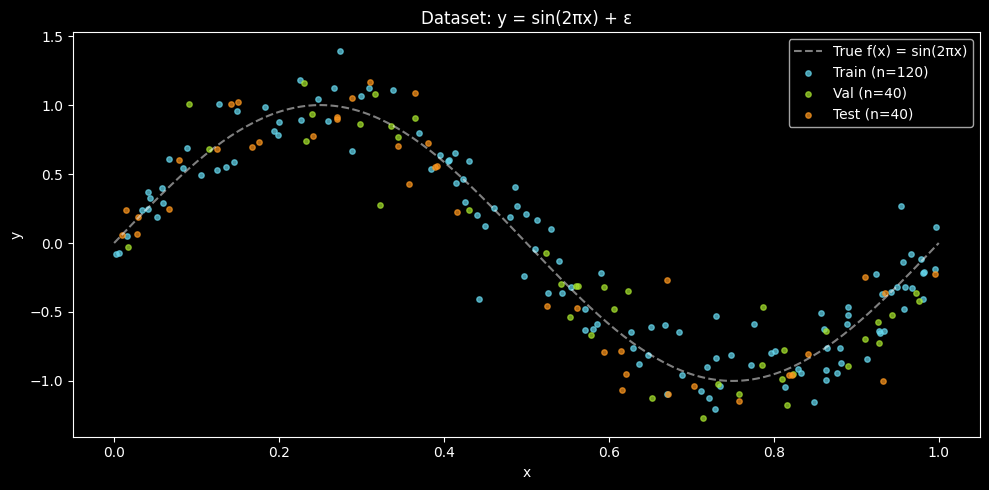

In [4]:
x_curve = np.linspace(0, 1, 200)
y_curve = np.sin(2 * np.pi * x_curve)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_curve, y_curve, 'w--', alpha=0.5, label='True f(x) = sin(2πx)')
ax.scatter(data['x_train'], data['y_train'], c='#66d9ef', s=15, alpha=0.7, label=f"Train (n={data['x_train'].shape[0]})")
ax.scatter(data['x_val'],   data['y_val'],   c='#a6e22e', s=15, alpha=0.7, label=f"Val (n={data['x_val'].shape[0]})")
ax.scatter(data['x_test'],  data['y_test'],  c='#fd971f', s=15, alpha=0.7, label=f"Test (n={data['x_test'].shape[0]})")
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Dataset: y = sin(2πx) + ε')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 1: Choose Model — Shallow Neural Network

### Architecture

$$\hat{y} = f(x; \boldsymbol{\phi}) = W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2$$

```
Input (1) ──→ [Linear] ──→ [ReLU] ──→ [Linear] ──→ Output (1)
              W₁∈ℝ^(1×H)            W₂∈ℝ^(H×1)
              b₁∈ℝ^H                b₂∈ℝ^1
```

### Model details

| Component | Shape | Description |
|-----------|-------|-----------|
| $W_1$ | $(1, H)$ | Input-to-hidden weights |
| $b_1$ | $(H,)$ | Hidden biases |
| $\text{ReLU}(z) = \max(0, z)$ | pointwise | Nonlinear activation |
| $W_2$ | $(H, 1)$ | Hidden-to-output weights |
| $b_2$ | $(1,)$ | Output bias |

**Total parameters:** $P = H + H + H + 1 = 3H + 1$

**Capacity** is controlled by the hidden dimension $H$ (Prince §2.3):
- Small $H$ → low capacity → **underfitting** risk (hypothesis space too restricted)
- Large $H$ → high capacity → **overfitting** risk (model can memorise noise)

**Initialisation:** He init — $W \sim \mathcal{N}(0, 2/n_{\text{in}})$ — good default for ReLU.

In [5]:
class ShallowNet:
    """y = W₂ · ReLU(W₁x + b₁) + b₂"""

    def __init__(self, input_dim=1, hidden_dim=20, seed=SEED):
        rng = np.random.default_rng(seed)
        self.W1 = rng.standard_normal((input_dim, hidden_dim)) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.standard_normal((hidden_dim, 1)) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros(1)
        self._cache = {}

    @property
    def num_params(self):
        return self.W1.size + self.b1.size + self.W2.size + self.b2.size

    def forward(self, x):
        z1 = x @ self.W1 + self.b1
        a1 = np.maximum(z1, 0.0)     # ReLU
        y_hat = a1 @ self.W2 + self.b2
        self._cache = {'x': x, 'z1': z1, 'a1': a1}
        return y_hat

    def backward(self, grad_y):
        x, z1, a1 = self._cache['x'], self._cache['z1'], self._cache['a1']
        batch = x.shape[0]
        grad_W2 = (a1.T @ grad_y) / batch
        grad_b2 = grad_y.mean(axis=0)
        grad_a1 = grad_y @ self.W2.T
        grad_z1 = grad_a1 * (z1 > 0).astype(float)
        grad_W1 = (x.T @ grad_z1) / batch
        grad_b1 = grad_z1.mean(axis=0)
        return {'W1': grad_W1, 'b1': grad_b1, 'W2': grad_W2, 'b2': grad_b2}

    def update(self, grads, lr):
        for key in ['W1', 'b1', 'W2', 'b2']:
            setattr(self, key, getattr(self, key) - lr * grads[key])

---
## Step 2: Choose Loss — Mean Squared Error

$$\mathcal{L}[\boldsymbol{\phi}] = \frac{1}{I}\sum_{i=1}^{I} (\hat{y}_i - y_i)^2$$

**Why MSE?** Under Gaussian noise assumption $y \sim \mathcal{N}(f(x; \phi), \sigma^2)$, minimising MSE = maximising log-likelihood (Prince §2.3):

$$\text{MSE} = -\frac{1}{I}\log\prod_i p(y_i \mid x_i, \boldsymbol{\phi}) + \text{const}$$

**Gradient:** $\frac{\partial \mathcal{L}}{\partial \hat{y}_i} = \frac{2}{I}(\hat{y}_i - y_i)$

In [6]:
def mse_loss(y_hat, y):
    """MSE loss and gradient. Returns (loss, grad_y_hat)."""
    residual = y_hat - y
    loss = float(np.mean(residual ** 2))
    grad = 2.0 * residual / y.shape[0]
    return loss, grad

---
## Step 3: Fit Model — Mini-Batch Gradient Descent

### ERM objective (Prince §2.4)

$$\boldsymbol{\phi}^* = \arg\min_{\boldsymbol{\phi}} \frac{1}{I}\sum_{i=1}^{I} \ell\big(f(\mathbf{x}_i; \boldsymbol{\phi}),\, y_i\big)$$

### Update rule (Prince §2.8)

$$\boldsymbol{\phi} \leftarrow \boldsymbol{\phi} - \alpha \nabla_{\boldsymbol{\phi}} \mathcal{L}$$

**Mini-batch SGD:** Use a random subset $\mathcal{B}$ of size $B$. The mini-batch gradient is an **unbiased estimator** of the full gradient:

$$\mathbb{E}_{\mathcal{B}}\left[\frac{1}{B}\sum_{j \in \mathcal{B}} \nabla\ell_j\right] = \nabla\mathcal{L}$$

In [7]:
def train(model, data, lr=0.1, epochs=500, batch_size=32, seed=SEED):
    """Mini-batch gradient descent. Returns loss history."""
    rng = np.random.default_rng(seed)
    x_tr, y_tr = data['x_train'], data['y_train']
    n = x_tr.shape[0]
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        perm = rng.permutation(n)
        for start in range(0, n, batch_size):
            xb = x_tr[perm[start:start+batch_size]]
            yb = y_tr[perm[start:start+batch_size]]
            y_hat = model.forward(xb)
            _, grad = mse_loss(y_hat, yb)
            grads = model.backward(grad)
            model.update(grads, lr)

        tr_loss, _ = mse_loss(model.forward(x_tr), y_tr)
        va_loss, _ = mse_loss(model.forward(data['x_val']), data['y_val'])
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)

    return history

def evaluate(model, data):
    """Evaluate on all splits."""
    return {s: mse_loss(model.forward(data[f'x_{s}']), data[f'y_{s}'])[0]
            for s in ['train', 'val', 'test']}

---
## Step 4: Evaluate — Comparing Model Capacities

We train **two models** to observe underfitting vs good fit:

| Config | Hidden dim $H$ | Parameters $P$ | Expected behaviour |
|--------|---------------|----------------|--------------------|
| Low capacity | 4 | 13 | Underfitting: both train & val loss high |
| Good capacity | 20 | 61 | Good fit: both losses near σ² = 0.04 |

In [8]:
configs = [
    {'name': 'Low capacity (H=4)',  'hidden_dim': 4,  'color': '#f92672'},
    {'name': 'Good capacity (H=20)', 'hidden_dim': 20, 'color': '#66d9ef'},
]

results_all = {}
histories = {}
models = {}

for cfg in configs:
    model = ShallowNet(hidden_dim=cfg['hidden_dim'], seed=SEED)
    print(f"\n{'─'*50}")
    print(f"{cfg['name']}  |  P = {model.num_params} parameters")
    print(f"{'─'*50}")

    hist = train(model, data)
    res = evaluate(model, data)
    gap = res['test'] - res['train']

    print(f"  Train: {res['train']:.6f}")
    print(f"  Val:   {res['val']:.6f}")
    print(f"  Test:  {res['test']:.6f}")
    print(f"  Gen gap: {gap:+.6f}")

    results_all[cfg['name']] = res
    histories[cfg['name']] = hist
    models[cfg['name']] = model


──────────────────────────────────────────────────
Low capacity (H=4)  |  P = 13 parameters
──────────────────────────────────────────────────
  Train: 0.231846
  Val:   0.278098
  Test:  0.320235
  Gen gap: +0.088388

──────────────────────────────────────────────────
Good capacity (H=20)  |  P = 61 parameters
──────────────────────────────────────────────────
  Train: 0.191715
  Val:   0.197028
  Test:  0.237292
  Gen gap: +0.045577


### Learning curves

**What to look for** (Prince §2.6):
- **Underfit:** Both curves high, roughly parallel → model can't capture the pattern
- **Overfit:** Train curve low, val curve high (diverging) → model memorises noise
- **Good fit:** Both curves low, roughly converged together

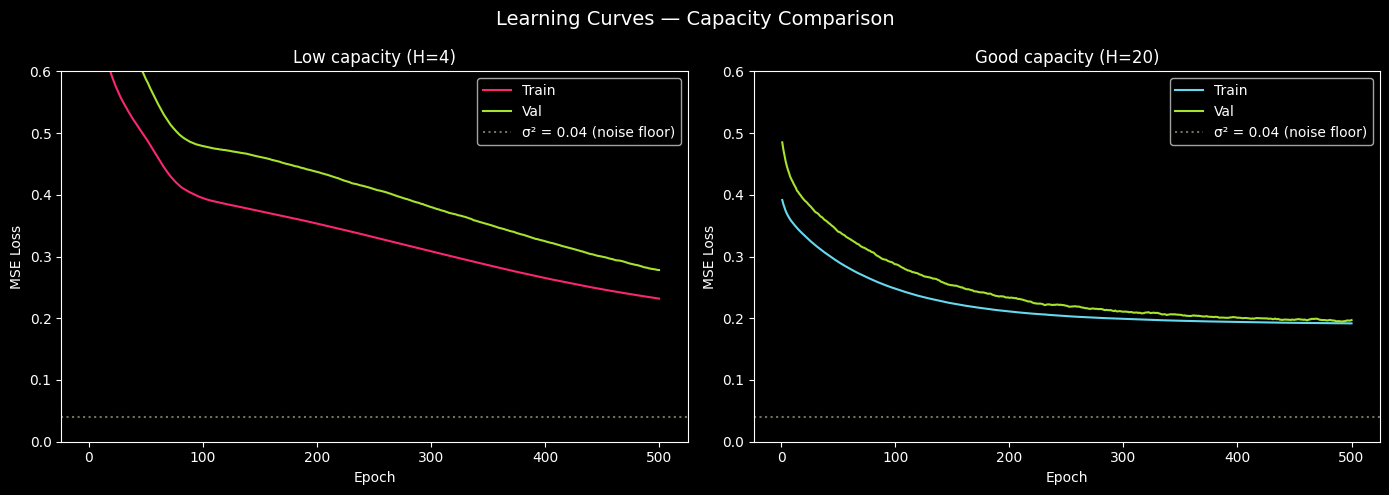

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cfg in zip(axes, configs):
    h = histories[cfg['name']]
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], color=cfg['color'], label='Train')
    ax.plot(epochs, h['val_loss'], color='#a6e22e', label='Val')
    ax.axhline(y=0.04, color='#75715e', linestyle=':', label='σ² = 0.04 (noise floor)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(cfg['name'])
    ax.legend()
    ax.set_ylim(0, 0.6)

plt.suptitle('Learning Curves — Capacity Comparison', fontsize=14)
plt.tight_layout()
plt.show()

### Fitted functions vs true function

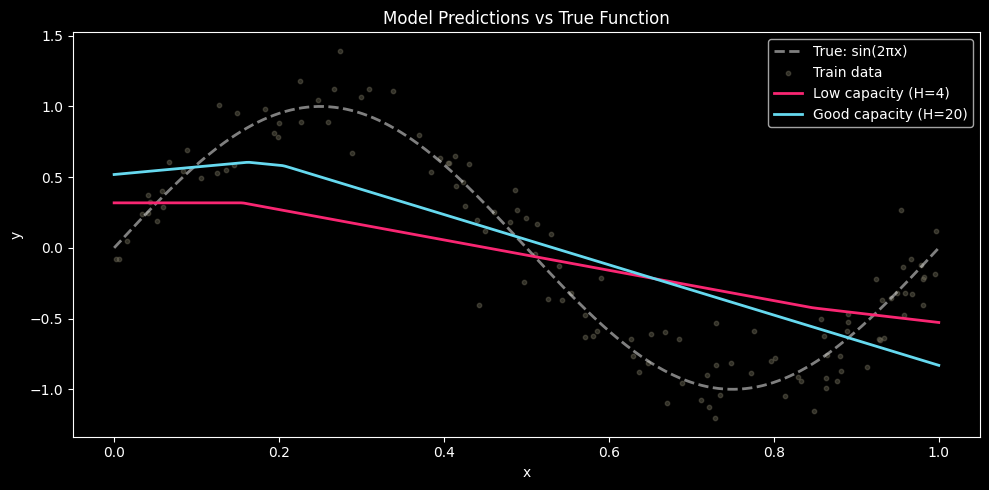

In [10]:
x_plot = np.linspace(0, 1, 300)[:, None]
y_true_plot = np.sin(2 * np.pi * x_plot)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_plot, y_true_plot, 'w--', alpha=0.5, linewidth=2, label='True: sin(2πx)')
ax.scatter(data['x_train'], data['y_train'], c='#75715e', s=10, alpha=0.4, label='Train data')

for cfg in configs:
    y_pred = models[cfg['name']].forward(x_plot)
    ax.plot(x_plot, y_pred, color=cfg['color'], linewidth=2, label=cfg['name'])

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Model Predictions vs True Function')
ax.legend()
plt.tight_layout()
plt.show()

---
## Analysis: Connecting to Prince Ch 2 Concepts

### Generalization gap (§2.5)

$$\text{Gap} = R[\boldsymbol{\phi}^*] - \hat{R}[\boldsymbol{\phi}^*] \approx \text{test\_loss} - \text{train\_loss}$$

The gap is driven by: **(1)** sample size (more data → smaller gap), **(2)** model complexity (more params → bigger gap), **(3)** regularisation.

### Bias-variance decomposition (§2.7)

$$\mathbb{E}[\text{Error}] = \text{Bias}^2 + \text{Variance} + \sigma^2$$

- **σ² = 0.04** is the irreducible noise floor — no model can go below this
- **Low capacity** → high bias (can't represent the true function) + low variance
- **High capacity** → low bias + higher variance (sensitive to training data)

In [11]:
print("Summary")
print("=" * 55)
print(f"{'Config':<25} {'Train':>8} {'Val':>8} {'Test':>8} {'Gap':>8}")
print("-" * 55)
for cfg in configs:
    r = results_all[cfg['name']]
    gap = r['test'] - r['train']
    print(f"{cfg['name']:<25} {r['train']:8.4f} {r['val']:8.4f} {r['test']:8.4f} {gap:+8.4f}")
print("-" * 55)
print(f"{'Noise floor (σ²)':<25} {'0.0400':>8}")
print()
print("OK")

Summary
Config                       Train      Val     Test      Gap
-------------------------------------------------------
Low capacity (H=4)          0.2318   0.2781   0.3202  +0.0884
Good capacity (H=20)        0.1917   0.1970   0.2373  +0.0456
-------------------------------------------------------
Noise floor (σ²)            0.0400

OK
